D'abord nous devons importer certains packages qui nous seront utiles plus tard. Avec l'aide de ces packages, nous pouvons par exemple lire les données et créer des graphes.

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

print('imported all modules')

imported all modules


Ensuite nous pouvons definir nos propres fonctions.

In [3]:
### Lis les leptons du fichier csv
def ReadLeptons(data, event):
  lepton1 = np.array([ data.values[event][0], data.values[event][1], data.values[event][2], data.values[event][3] ])
  lepton2 = np.array([ data.values[event][4], data.values[event][5], data.values[event][6], data.values[event][7] ])
  lepton3 = np.array([ data.values[event][8], data.values[event][9], data.values[event][10], data.values[event][11] ])
  lepton4 = np.array([ data.values[event][12], data.values[event][13], data.values[event][14], data.values[event][15] ])
  return [ lepton1, lepton2, lepton3, lepton4 ]

### Lis le poids de l'événement du fichier csv
def ReadWeight(data, event):
  return data.values[event][16]

### Calcule l'énergie des particules
def Energy(p):
  return p[3]

### Calcule le pT des particules
def Pt(p):
  pt = math.sqrt( p[0]*p[0] + p[1]*p[1] )
  return pt

### Calcule la masse des particules
def Mass(p):
  mass = 0
  '''
  Ici vous avez besoin de calculer la masse
  La formule est:
  m2 = - px*px - py*py - pz*pz + E*E

  Si m2 > 0, vous pouvez prendre la racine:
  mass = math.sqrt( m2 )

  Si m2 < 0, on devrait mettre la valeur à 0:
  mass = 0
  '''
  return mass

### fonction pour dessiner les graphes
def plot(nbins, min, max, datavalues, mcvalues, mcweights, mcnames, xlabel):
  fig = plt.figure()
  fig.subplots_adjust()
  ax1 = fig.add_subplot()
  ax1.set_ylabel('Events')
  ax1.set_xlabel(xlabel)
  plt.hist( mcvalues, weights = mcweights , bins=nbins, range=(min,max), label=mcnames, stacked=True )
  datahist,bins = np.histogram(datavalues, bins=nbins, range=(min,max))
  binsize = (max-min)/nbins
  real_bins = [x+binsize/2 for x in bins]
  del real_bins[-1]
  yerror = [math.sqrt(x) for x in datahist]
  xerror = [binsize/2 for x in datahist]
  plt.errorbar( real_bins, datahist, yerr=yerror, xerr=xerror, label="Data", fmt='o', color="black" )
  plt.legend(loc="upper right")
  plt.show()

### fonction Print pour voir l'avancée de la lecture
def PrintProgress(event, Nevents):
  percentage = PrintProgress.counter*0.2
  if event > percentage*Nevents:
    print('   - ',int(percentage*100),'% (',event, 'of', Nevents, 'events processed)')
    PrintProgress.counter += 1
  if event == Nevents-1:
    PrintProgress.counter = 0
PrintProgress.counter = 0

def get_totals(data, mcvalues, mcweights, range):
  h_data = np.histogram(data, bins=2, range=range)
  h_signal = np.histogram(mcvalues[0], bins=2, range=range, weights=mcweights[0])
  h_bkg = np.histogram(mcvalues[1], bins=2, range=range, weights=mcweights[1])
  return h_data, h_signal, h_bkg

pathtocsv = 'https://raw.githubusercontent.com/abenecke/PPT_csv/master/'

print('defined all functions and variables')

defined all functions and variables


Maintenant on va lire les données. Les données sont stockées [ici]() dans un fichier format csv et on peut les lire à partir de là.

<div>
  <center>
    <img src="https://raw.githubusercontent.com/abenecke/PPT_csv/master/CSV.png" width="500"/>
  </center>
</div>



In [4]:
### Lecture des données
LepEnergyData = []
LepPtData = []

### fichier de donnée qu'on lit, actuellement uniquement des données de 2011 et 2012 dans le canal des électrons et muons
Datafiles = [
             'DATA_Electron_2011.csv',
             'DATA_Muon_2011.csv',
             'DATA_Electron_2012.csv',
             'DATA_Muon_2012.csv'
]
for filename in Datafiles:
  print('start with', filename)
  csvdata = pd.read_csv(pathtocsv+filename, header=None)
  Nevents = len(csvdata)
  for event in range(Nevents):
    PrintProgress(event,Nevents)

    ### Ici commence le code d'analyse : pour chaque événement dans le fichier csv, le code suivant est exécuté
    Leptons = ReadLeptons(csvdata, event)


    energy = Energy(Leptons[0]) ### recupère l'énergie du premier lepton dans l'événement
    pt = Pt(Leptons[0]) ### recupère le pT du premier lepton dans l'événement
    LepEnergyData.append(energy) ### stocke l'énergie du premier lepton de chaque événement
    LepPtData.append(pt) ### stocke le pT du premier lepton de chaque événement


    #########

  print('   - done')


start with DATA_Electron_2011.csv
   -  0 % ( 1 of 7 events processed)
   -  20 % ( 2 of 7 events processed)
   -  40 % ( 3 of 7 events processed)
   -  60 % ( 5 of 7 events processed)
   -  80 % ( 6 of 7 events processed)
   - done
start with DATA_Muon_2011.csv
   -  0 % ( 1 of 31 events processed)
   -  20 % ( 7 of 31 events processed)
   -  40 % ( 13 of 31 events processed)
   -  60 % ( 19 of 31 events processed)
   -  80 % ( 25 of 31 events processed)
   - done
start with DATA_Electron_2012.csv
   -  0 % ( 1 of 41 events processed)
   -  20 % ( 9 of 41 events processed)
   -  40 % ( 17 of 41 events processed)
   -  60 % ( 25 of 41 events processed)
   -  80 % ( 33 of 41 events processed)
   - done
start with DATA_Muon_2012.csv
   -  0 % ( 1 of 199 events processed)
   -  20 % ( 40 of 199 events processed)
   -  40 % ( 80 of 199 events processed)
   -  60 % ( 120 of 199 events processed)
   -  80 % ( 160 of 199 events processed)
   - done


Maintenant on lit les événements simulés du processus ZZ->4l, qui sont des événements d'arrière-plan pour notre analyse.
<div>
  <center>
    <img src="https://raw.githubusercontent.com/abenecke/PPT_csv/master//ZZ.png" width="400"/>
  </center>
</div>



In [5]:
### Lecture des événements d'arrière-plan ZZ simulés
LepEnergyZZ = []
LepPtZZ = []
WeightsZZ = []

ZZfiles = [
### Inserez tous les fichiers MC_ZZ*.csv que vous pouvez trouver: https://github.com/abenecke/PPT_csv
]
for filename in ZZfiles:
  print('start with', filename)
  csvdata = pd.read_csv(pathtocsv+filename, header=None)
  Nevents = len(csvdata)
  for event in range(Nevents):
    PrintProgress(event, Nevents)

    ### Ici commence le code d'analyse
    Leptons = ReadLeptons(csvdata, event)
    weight = ReadWeight(csvdata, event) ### le poids des événements est uniquement nécessaire pour les événements simulés
    WeightsZZ.append(weight) ### stocke tous les poids d'événement

    energy = Energy(Leptons[0])
    pt = Pt(Leptons[0])
    LepEnergyZZ.append(energy)
    LepPtZZ.append(pt)
    #########

  print('   - done')

Maintenant on lit les événements de signal simulés: Higgs->4l.

<div>
  <center>
    <img src="https://raw.githubusercontent.com/abenecke/PPT_csv/master/Higgs4l.png" width="400"/>
  </center>
</div>

In [6]:
### Lecture des événements simulés par Higgs (signal)
LepEnergyHiggs = []
LepPtHiggs = []
WeightsHiggs = []

Higgsfiles = [
### Inserez tous les fichiers MC_ZZ*.csv que vous pouvez trouver: https://github.com/abenecke/PPT_csv
]
for filename in Higgsfiles:
  print('start with', filename)
  csvdata = pd.read_csv(pathtocsv+filename, header=None)
  Nevents = len(csvdata)
  for event in range(Nevents):
    PrintProgress(event, Nevents)

    ### Ici commence le code d'analyse:
    Leptons = ReadLeptons(csvdata, event)
    weight = ReadWeight(csvdata, event)
    # Vous aurez besoin de remplir le même type de variables que pour le ZZ d'arrière-plan

    #########

  print('   - done')

On doit maintenant créer les histogrammes avec la fonction definie plus tôt: 'plot'. La fonction a besoin des arguments suivants:

*   nbins: nombre de catégories
*   min: minimum
*   max: maximum
*   data: liste des valeurs dans les données
*   mcdatalist: liste des mesures dans la simulation
*   weights: liste des poids dans la simulation
*   labels: liste des noms pour la simulation
*   xlabel: titre de l'axe x

`plot(nbins, min, max, data, mcdatalist, weights, labels, xlabel)`



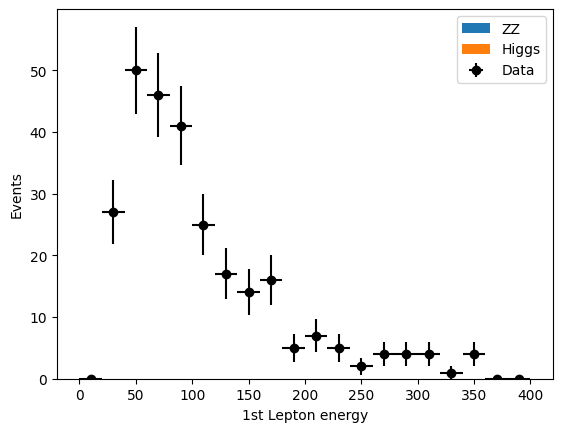

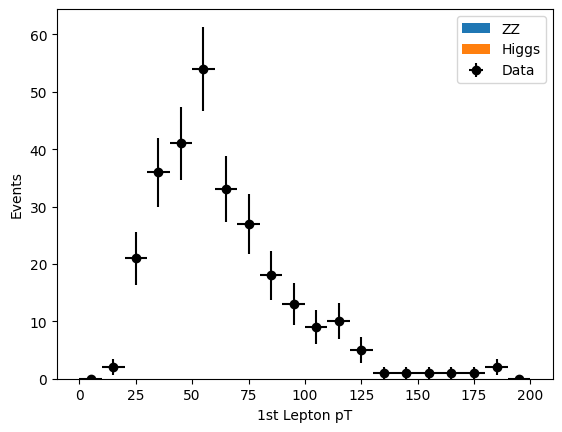

In [7]:
### deux exemples d'histogramme
plot(20, 0, 400, LepEnergyData, [LepEnergyZZ, LepEnergyHiggs], [ WeightsZZ, WeightsHiggs] , [ 'ZZ', 'Higgs' ], '1st Lepton energy')
plot(20, 0, 200, LepPtData, [LepPtZZ, LepPtHiggs], [ WeightsZZ, WeightsHiggs] , [ 'ZZ', 'Higgs' ], '1st Lepton pT')


# Significativité du signal

Nous pouvons effectuer une analyse pour étudier l'importance du signal par rapport au bruit de fond. Une méthode consiste à examiner une quantité appelée significativité du signal $S$, définie par
$$S = \frac{N_\mathrm{sig}}{N_\mathrm{bkg}}$$
où $N_\mathrm{sig}$ et $N_\mathrm{bkg}$ représentent respectivement le nombre de points correspondant au signal et au bruit de fond. Une valeur de $S$ plus grande correspond à un meilleur rapport signal sur bruit de fond, et à un pic de signal plus significatif.

In [ ]:
# Ajoutez la distribution de la masse invariante à cette fonction
data = None # Que faut-il mettre ici ?
signal = None # Que faut-il mettre ici ?
bkg = None # Que faut-il mettre ici ?
mcweights = [WeightsZZ, WeightsHiggs]
data, signal, bkg = get_totals(data, [signal, bkg], mcweights, range=(0,0)) 

def significance(data, signal, bkg):
    sig = 0
    """
    vous devez calculer la significativité ici
    """
    return sig

sig = significance(data, signal, bkg)

print(f"Significativité observée : {sig:.2f}")